## Sentiment shifts -  FULL DATASET ANALYSIS ONLY

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8") #--> Sample dataset input

df = pd.read_csv("../ParlaMint-SI_full_dataset.tsv", sep="\t", encoding="utf-8") #--> Full dataset input
df = df[df["Speaker_role"] != "Chairperson"]
df.head()

,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,lrgen,galtan,Family,Seat
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
3,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u4,"Spoštovane poslanke in poslanci, lep pozdrav p...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,3.51,29,562,662,-,2013,NaN,NaN,NaN,NaN
5,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u6,Hvala lepa še enkrat za besedo. Spoštovana pre...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.16,14,227,266,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
7,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u8,Najlepša hvala. Spoštovani poslanec! Jaz misli...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,2.72,18,226,269,-,2013,NaN,NaN,NaN,NaN
9,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u10,Res je. Hvala še enkrat za besedo. Na podlagi ...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,1.28,7,111,130,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN


## Sample visualisations

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = pd.to_datetime(df["Year"])

cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV"]
df = df[~df.isin(cols)]

## Coal-oppo sample

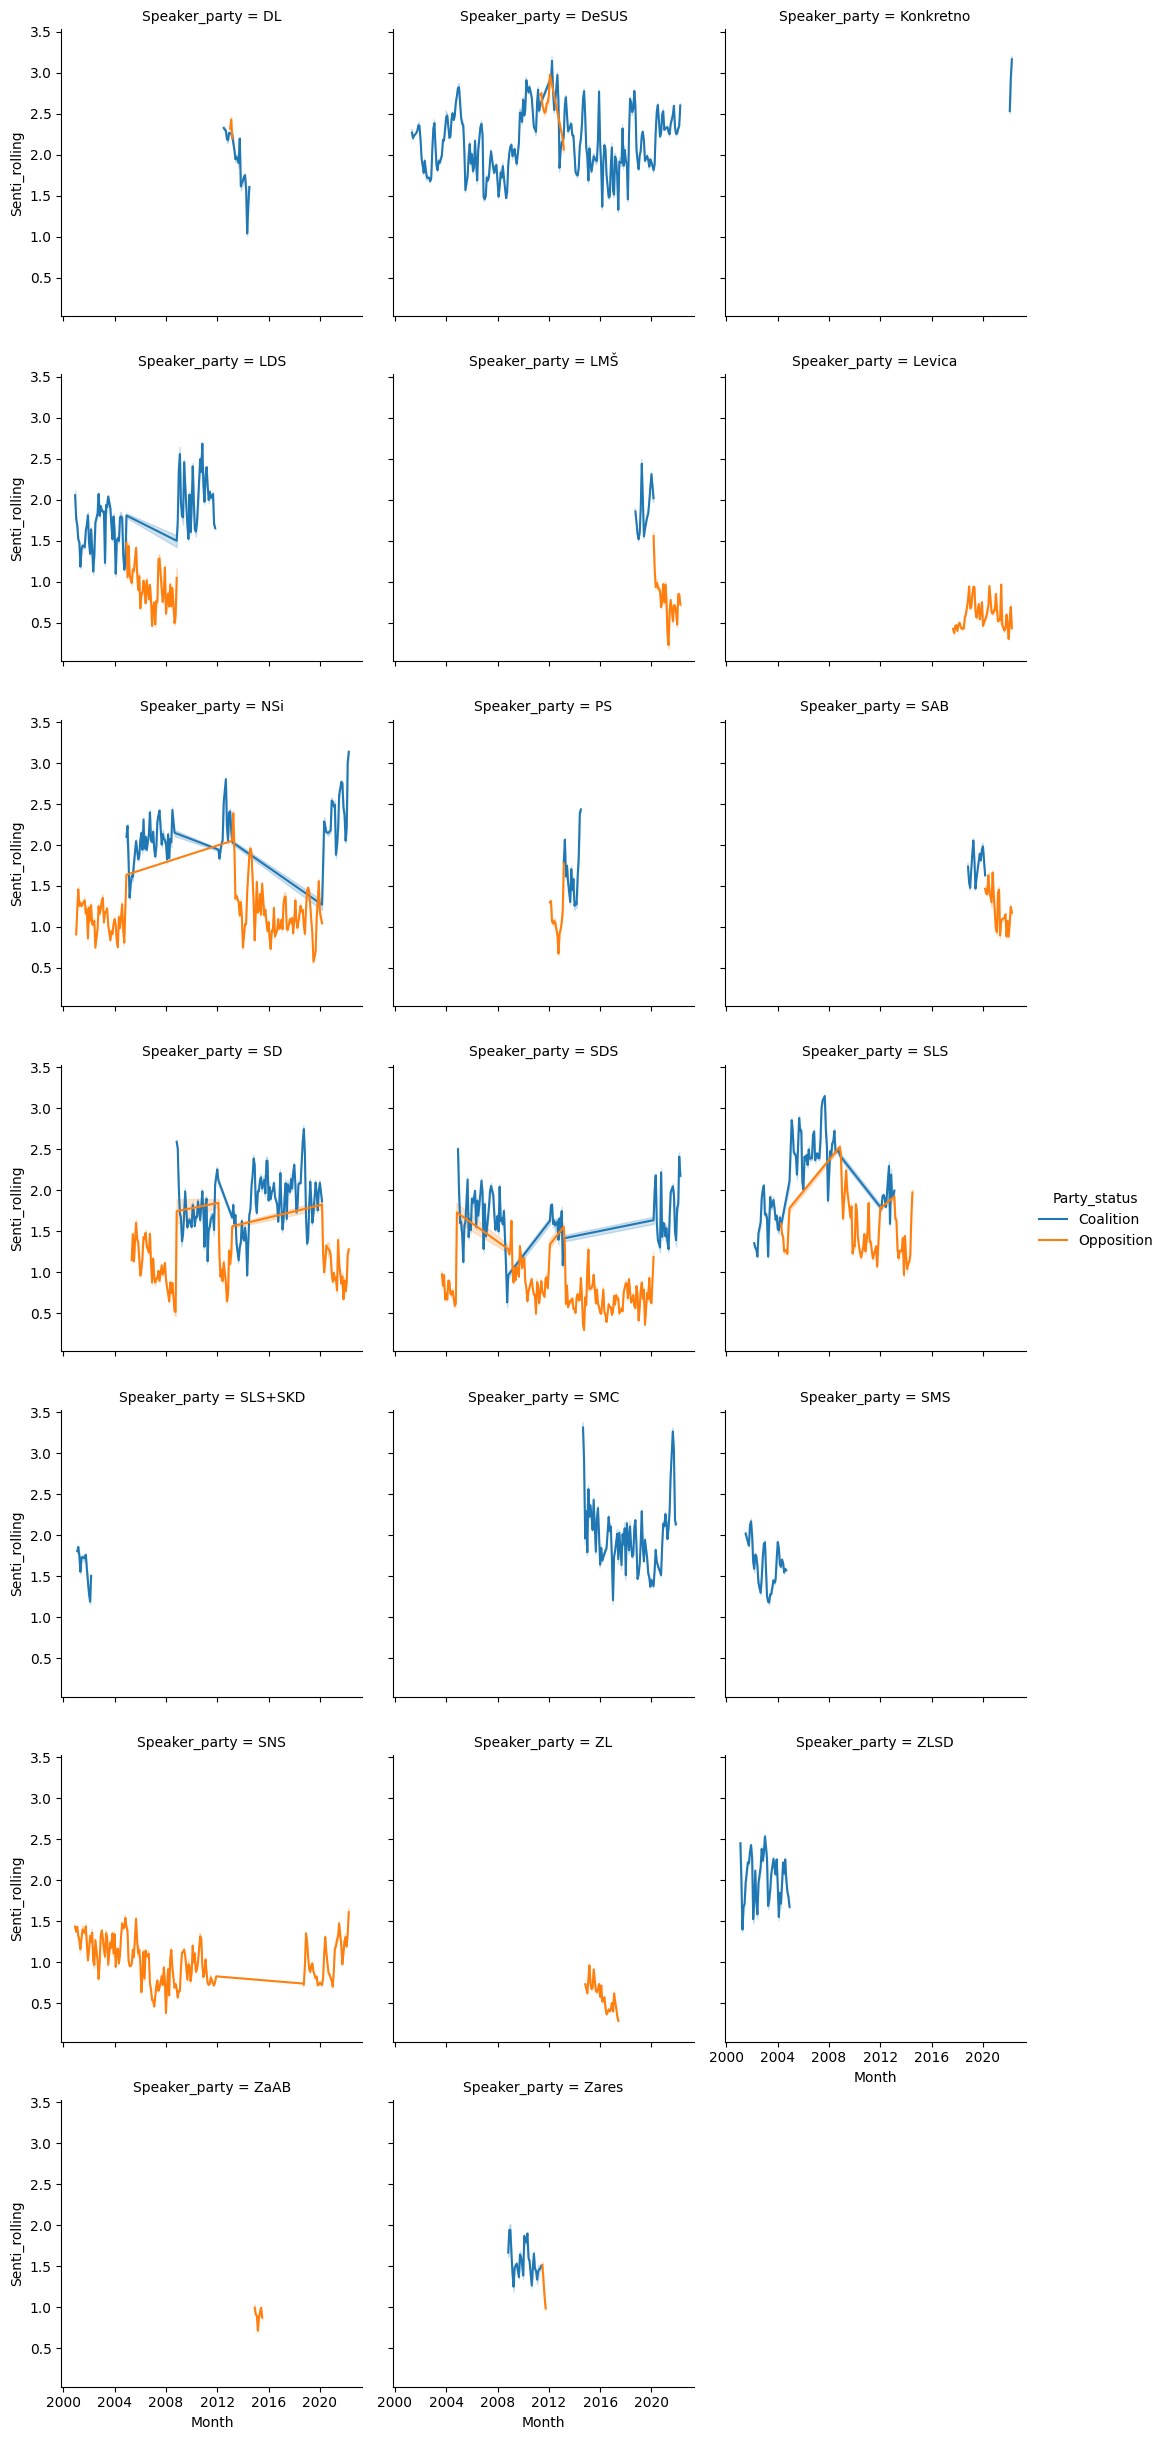

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()
df = df.sort_values(['Speaker_party', 'Date'])

# Compute rolling mean sentiment over last 30 speeches per party
df['Senti_rolling'] = df.groupby('Speaker_party')['Senti_n'].transform(
    lambda x: x.rolling(65).mean()
)

sns.relplot(
    data=df, x="Month", y='Senti_rolling', hue='Party_status',
    kind='line', col='Speaker_party', col_wrap=3, height=3.5
)
plt.show()

## Whole dataset only plots

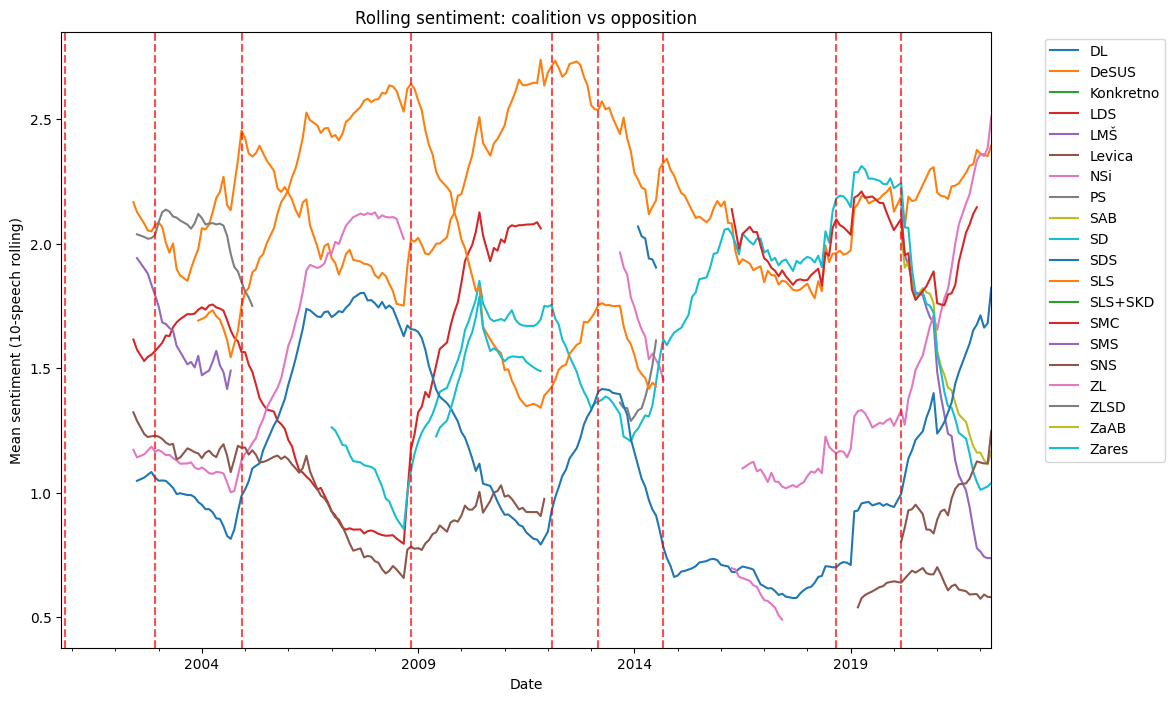

In [5]:
#Dummy gov dates to test for the whole dataset plotting
df["Year"] = df["Year"].astype(int)

gov_changes = [
    ("2000-11-30", "6. Gov (Drnovšek)"),
    ("2002-12-19", "7. Gov (Rop)"),
    ("2004-12-03", "8. Gov (Janša)"),
    ("2008-11-21", "9. Gov (Pahor)"), 
    ("2012-02-10", '10. Gov (Janša)'),
    ("2013-03-20", '11. Gov (Bratušek)'), 
    ("2014-09-18", '12. Gov (Cerar)'),
    ("2018-09-13", '13. Gov (Šarec)'),
    ('2020-03-13', '14. Gov (Janša)'),
    
]
trend_blocs = (
    df.groupby([df["Date"].dt.to_period("M"),'Speaker_party'])['Senti_n']
      .mean().unstack().rolling(20).mean()
)
trend_blocs.plot(figsize=(12,8))
for date, label in gov_changes:
    plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
plt.title("Rolling sentiment: coalition vs opposition")
plt.ylabel("Mean sentiment (10-speech rolling)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

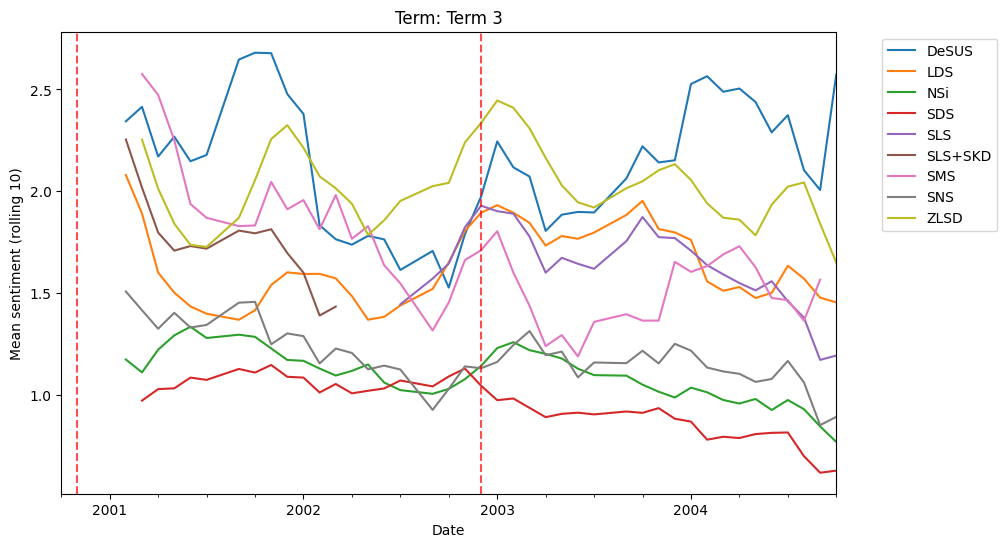

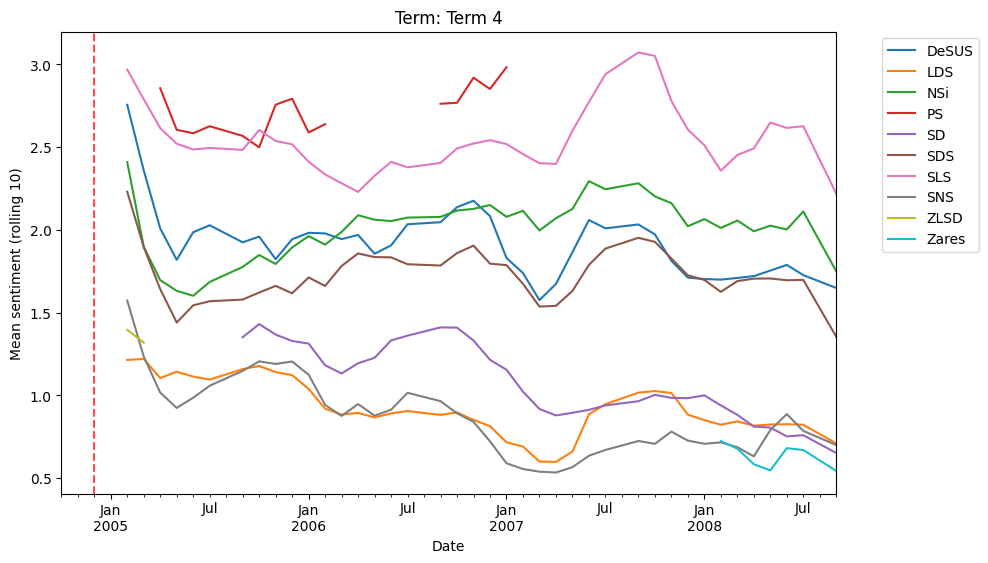

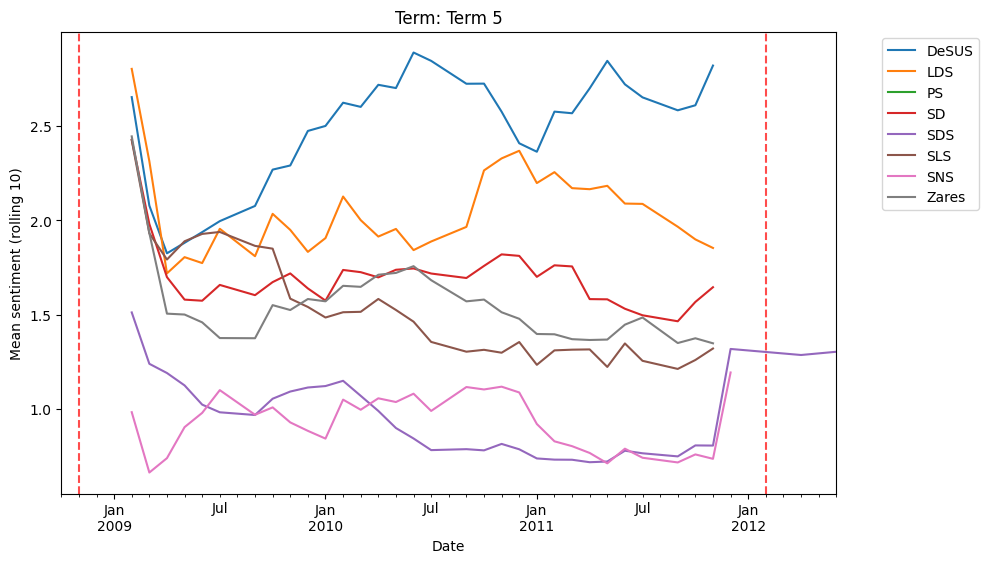

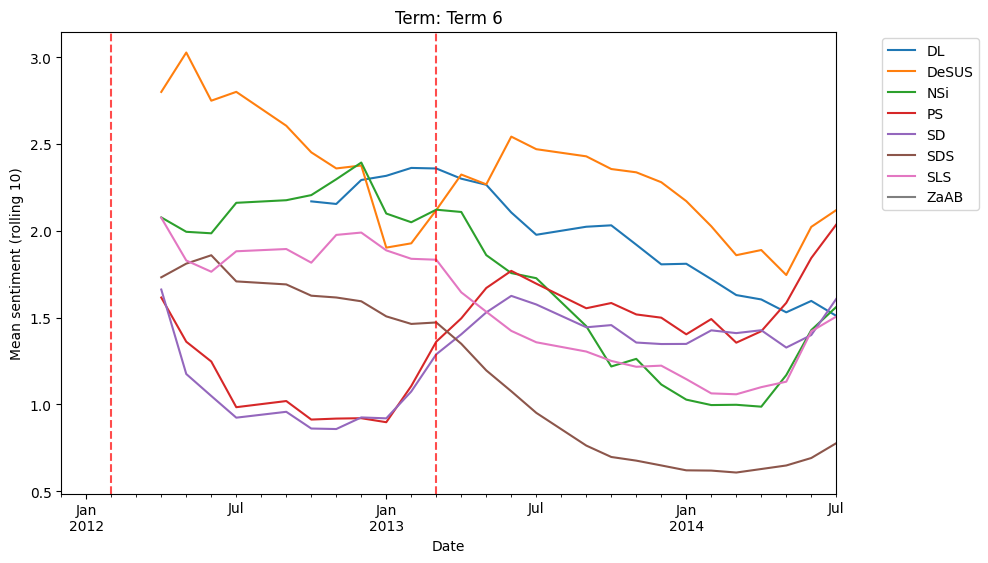

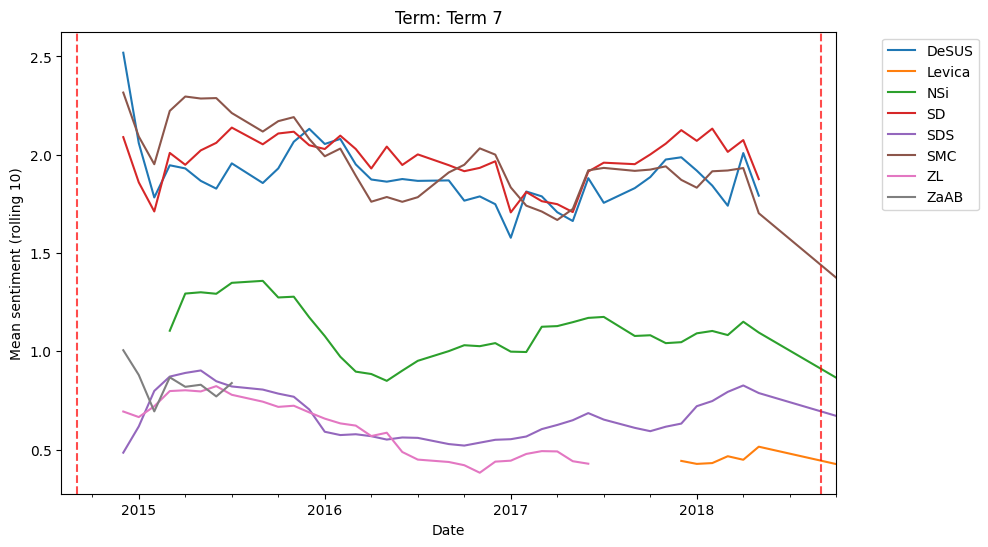

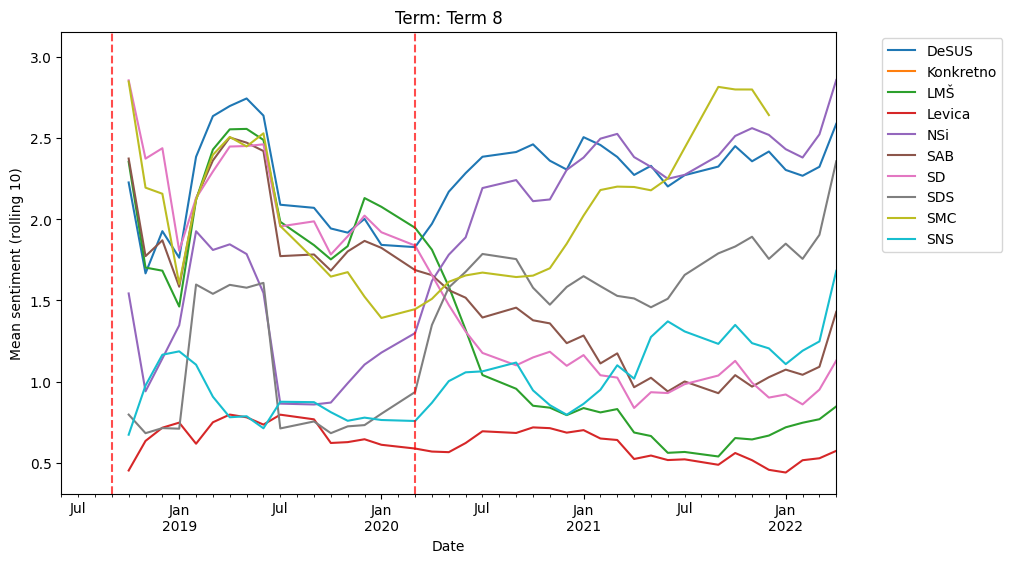

In [6]:
#Individual Term plots (with all government changes in each Term)
for term, sub in df.groupby('Term'):
    trend = sub.groupby([df["Date"].dt.to_period("M"),'Speaker_party'])['Senti_n'].mean().unstack().rolling(5).mean()
    trend.plot(figsize=(10,6), title=f"Term: {term}")
    plt.ylabel("Mean sentiment (rolling 10)")
    for date, label in gov_changes:
        if sub['Date'].min() <= pd.Timestamp(date) <= sub['Date'].max():
            plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.show()

In [7]:
gov_changes = [(pd.Timestamp(d), name) for d, name in gov_changes]
gov_changes

[(Timestamp('2000-11-30 00:00:00'), '6. Gov (Drnovšek)'),
 (Timestamp('2002-12-19 00:00:00'), '7. Gov (Rop)'),
 (Timestamp('2004-12-03 00:00:00'), '8. Gov (Janša)'),
 (Timestamp('2008-11-21 00:00:00'), '9. Gov (Pahor)'),
 (Timestamp('2012-02-10 00:00:00'), '10. Gov (Janša)'),
 (Timestamp('2013-03-20 00:00:00'), '11. Gov (Bratušek)'),
 (Timestamp('2014-09-18 00:00:00'), '12. Gov (Cerar)'),
 (Timestamp('2018-09-13 00:00:00'), '13. Gov (Šarec)'),
 (Timestamp('2020-03-13 00:00:00'), '14. Gov (Janša)')]

In [15]:
from pandas.api.types import CategoricalDtype

sentiment_shifts = []

for i, (change_date, gov_name) in enumerate(gov_changes):
    prev_date = gov_changes[i-1][0] if i > 0 else df['Date'].min()
    next_date = gov_changes[i+1][0] if i+1 < len(gov_changes) else df['Date'].max()
    
    # Define period window (one year before/after for example)
    before = df[(df['Date'] >= prev_date) & (df['Date'] < change_date)]
    after  = df[(df['Date'] >= change_date) & (df['Date'] < next_date)]
    
    # Compute mean sentiment by party or bloc
    before_mean = before.groupby('Speaker_party')['Senti_n'].mean().rename('Before')
    after_mean  = after.groupby('Speaker_party')['Senti_n'].mean().rename('After')
    
    merged = pd.concat([before_mean, after_mean], axis=1)
    merged['Change'] = merged['After'] - merged['Before']
    merged['Gov_change'] = gov_name
    sentiment_shifts.append(merged.reset_index())

sentiment_shift_df = pd.concat(sentiment_shifts, ignore_index=True)
sentiment_shift_df

gov_order = CategoricalDtype(['6. Gov (Drnovšek)', '7. Gov (Rop)', '8. Gov (Janša)', '9. Gov (Pahor)', '10. Gov (Janša)', '11. Gov (Bratušek)', '12. Gov (Cerar)', '13. Gov (Šarec)', '14. Gov (Janša)'], ordered=True)
sentiment_shift_df['Gov_change'] = sentiment_shift_df['Gov_change'].astype(gov_order)

sentiment_shift_df


,Speaker_party,Before,After,Change,Gov_change
0,DeSUS,3.203333,2.056689,-1.146645,6. Gov (Drnovšek)
1,LDS,2.901000,1.528769,-1.372231,6. Gov (Drnovšek)
2,NSi,1.613333,1.184643,-0.428690,6. Gov (Drnovšek)
3,SDS,2.740000,1.061498,-1.678502,6. Gov (Drnovšek)
4,SLS+SKD,2.702222,1.592925,-1.109297,6. Gov (Drnovšek)
...,...,...,...,...,...
89,SD,1.844199,1.018804,-0.825395,14. Gov (Janša)
90,SDS,0.747137,1.689168,0.942030,14. Gov (Janša)
91,SMC,1.638247,2.080694,0.442447,14. Gov (Janša)
92,SNS,0.907553,1.167805,0.260252,14. Gov (Janša)


In [21]:
sentiment_shift_df.pivot_table(
    index='Speaker_party', columns='Gov_change', values='Change', observed=True
).round(2)

Gov_change,6. Gov (Drnovšek),7. Gov (Rop),8. Gov (Janša),9. Gov (Pahor),10. Gov (Janša),11. Gov (Bratušek),12. Gov (Cerar),13. Gov (Šarec),14. Gov (Janša)
Speaker_party,,,,,,,,,
DL,NaN,NaN,NaN,NaN,NaN,-0.48,NaN,NaN,NaN
DeSUS,-1.15,0.24,-0.43,0.60,-0.17,-0.07,-0.31,0.04,0.46
LDS,-1.37,0.09,-0.69,1.07,NaN,NaN,NaN,NaN,NaN
LMŠ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.35,-1.04
Levica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.24,-0.11
NSi,-0.43,-0.15,0.97,0.02,0.23,-0.94,-0.23,0.04,1.31
PS,NaN,NaN,NaN,-0.93,-0.77,0.57,NaN,NaN,NaN
SAB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.37,-0.53
SD,NaN,NaN,NaN,0.60,-0.68,0.43,0.59,-0.18,-0.83


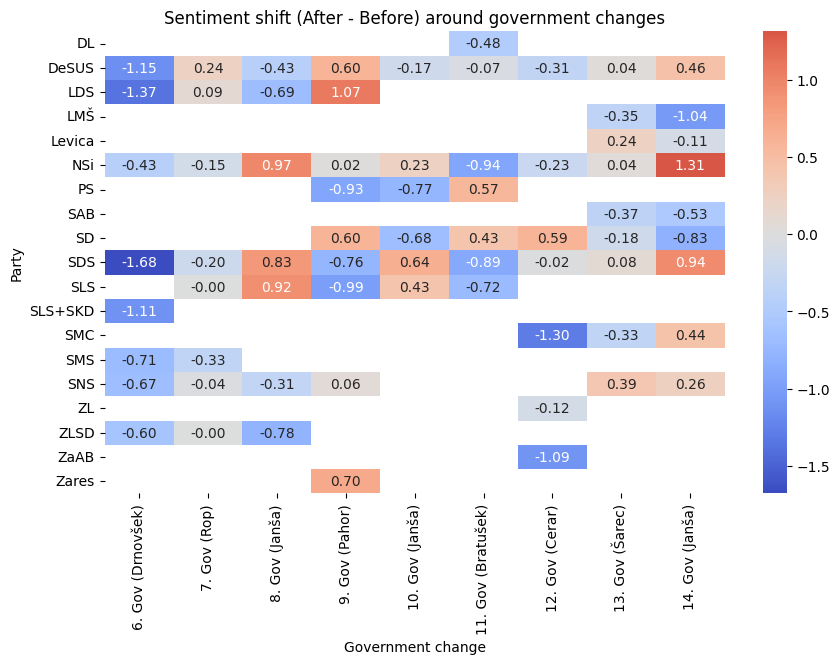

In [26]:
import seaborn as sns
plt.figure(figsize=(10,6))


sns.heatmap(
    sentiment_shift_df.pivot_table(
        index='Speaker_party', columns='Gov_change', observed=True, values='Change',
    ),
    cmap='coolwarm', center=0, annot=True, fmt=".2f"
)
plt.title('Sentiment shift (After - Before) around government changes')
plt.ylabel('Party')
plt.xlabel('Government change')
plt.show()

## Political orientation sentiment shifts

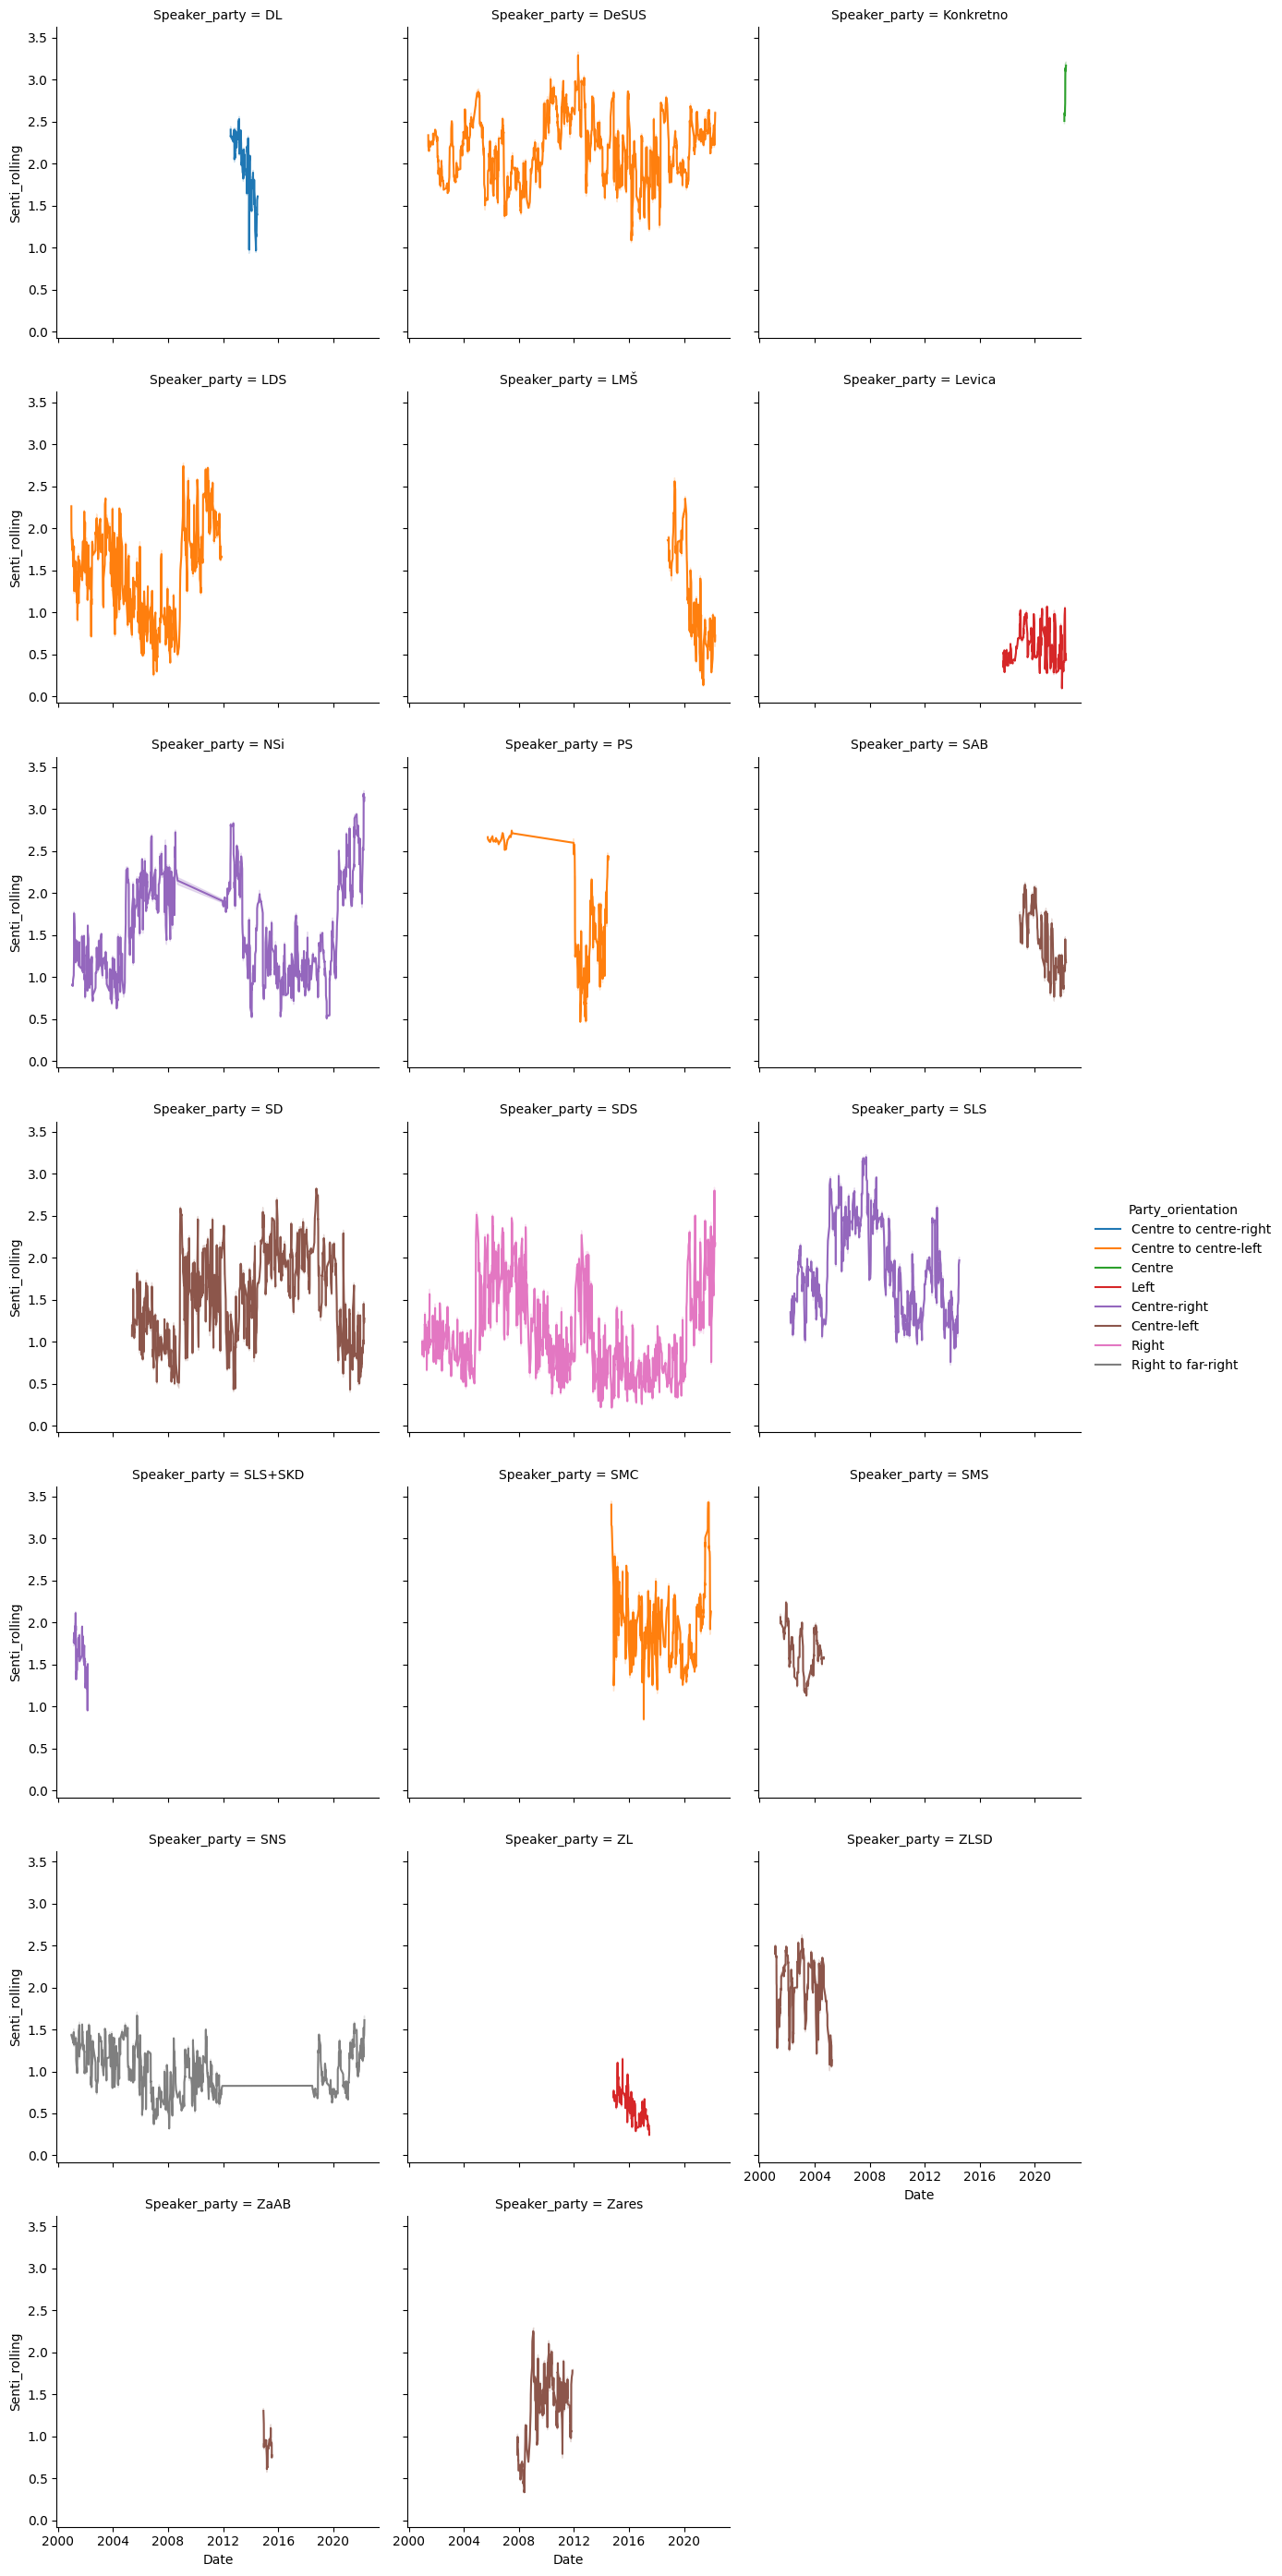

In [18]:
sns.relplot(
    data=df, x='Date', y='Senti_rolling', hue='Party_orientation',
    kind='line', col='Speaker_party', col_wrap=3, height=4
)
plt.show()